In [1]:
from a3em.datasets import arden
import os
from pathlib import Path

In [2]:
data_path = Path(os.getenv('DATA_PATH'))
X_train, X_test, y_train, y_test = arden.load_data(data_path, random_state=123)

loading audio data
checking for existing files
prefetch complete
extracting clip
extraction complete


In [3]:
X_train.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_17,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26
1383,50.781250,136.041199,121.249634,23.437500,190.429688,-12.391011,-10.225376,-255.938525,218.796739,-4.192700,...,0.007513,0.003078,0.002069,0.001523,0.000876,0.000868,2.919393e-04,4.086037e-05,5.507012e-06,2.216843e-06
1021,22.460938,127.224555,116.667415,21.484375,125.976562,-3.029788,2.989744,-273.496009,210.060162,6.592616,...,0.002980,0.001937,0.000710,0.000426,0.000257,0.000089,2.463619e-05,8.991935e-06,3.045565e-06,1.709949e-06
1395,48.828125,89.474324,88.220123,20.507812,108.398438,-3.400028,-2.241309,-267.578135,233.068617,31.117578,...,0.000451,0.000308,0.000175,0.000121,0.000076,0.000052,3.786912e-05,3.201613e-05,3.019629e-05,2.916804e-05
472,21.484375,104.493855,94.901037,20.507812,112.304688,-1.435793,1.257909,-305.428228,214.042846,42.963205,...,0.000137,0.000070,0.000041,0.000029,0.000016,0.000006,2.405915e-06,7.893328e-07,1.489344e-07,1.178652e-08
86,23.437500,111.463467,94.023517,22.460938,134.765625,-8.674582,-3.894047,-430.247425,210.038662,40.771570,...,0.000074,0.000035,0.000023,0.000017,0.000009,0.000002,5.316811e-07,1.529226e-07,3.419131e-08,6.414657e-09


In [4]:
y_train.head()

1383    0
1021    1
1395    0
472     1
86      1
Name: label, dtype: int64

In [5]:
X_train.to_csv('./data/train/features.csv')
X_test.to_csv('./data/test/features.csv')
y_train.to_csv('./data/train/labels.csv')
y_test.to_csv('./data/test/labels.csv')

## Analysis

In [6]:
import pandas as pd

In [7]:
train_features = pd.read_csv('./data/train/features.csv')
test_feature = pd.read_csv('./data/test/features.csv')
train_labels = pd.read_csv('./data/train/labels.csv')
test_labels = pd.read_csv('./data/test/labels.csv')

features_aggregate = pd.concat([train_features, test_feature], ignore_index=True)
labels_aggregate = pd.concat([train_labels, test_labels], ignore_index=True)

In [8]:
labels_aggregate['label'].value_counts()

label
0    1195
1     706
Name: count, dtype: int64

In [9]:
# Combine
df = train_features.copy().drop(columns=['Unnamed: 0'])
df['label'] = train_labels['label']

In [10]:
df.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26,label
0,50.781250,136.041199,121.249634,23.437500,190.429688,-12.391011,-10.225376,-255.938525,218.796739,-4.192700,...,0.003078,0.002069,0.001523,0.000876,0.000868,2.919393e-04,4.086037e-05,5.507012e-06,2.216843e-06,0
1,22.460938,127.224555,116.667415,21.484375,125.976562,-3.029788,2.989744,-273.496009,210.060162,6.592616,...,0.001937,0.000710,0.000426,0.000257,0.000089,2.463619e-05,8.991935e-06,3.045565e-06,1.709949e-06,1
2,48.828125,89.474324,88.220123,20.507812,108.398438,-3.400028,-2.241309,-267.578135,233.068617,31.117578,...,0.000308,0.000175,0.000121,0.000076,0.000052,3.786912e-05,3.201613e-05,3.019629e-05,2.916804e-05,0
3,21.484375,104.493855,94.901037,20.507812,112.304688,-1.435793,1.257909,-305.428228,214.042846,42.963205,...,0.000070,0.000041,0.000029,0.000016,0.000006,2.405915e-06,7.893328e-07,1.489344e-07,1.178652e-08,1
4,23.437500,111.463467,94.023517,22.460938,134.765625,-8.674582,-3.894047,-430.247425,210.038662,40.771570,...,0.000035,0.000023,0.000017,0.000009,0.000002,5.316811e-07,1.529226e-07,3.419131e-08,6.414657e-09,1


### Compute Summary Statistics

In [12]:
summary = df.groupby("label").mean()

std_summary = df.groupby("label").std()

comparison = pd.DataFrame({
    "Background Mean": df[df["label"] == 0].mean(),
    "Rumble Mean": df[df["label"] == 1].mean(),
    "Background Std": df[df["label"] == 0].std(),
    "Rumble Std": df[df["label"] == 1].std()
})

comparison = comparison.drop(index="label")
comparison

,Background Mean,Rumble Mean,Background Std,Rumble Std
peak_freq,33.441792,24.007314,10.475007,2.596039
centroid,148.430447,113.355128,30.162514,13.315003
bandwidth,123.707765,95.575827,18.264582,11.346128
freq_5,22.578081,23.019758,8.316331,2.338447
freq_95,215.174380,125.300481,70.105012,13.563902
hnr,-7.633131,0.137027,6.432906,3.445273
hnr_low,-6.220510,4.812156,7.067676,3.902437
mfcc_1,-233.731481,-282.331356,95.776929,40.294927
mfcc_2,217.276441,223.115765,15.756986,9.062406
mfcc_3,-5.275143,30.383249,28.445135,16.772643


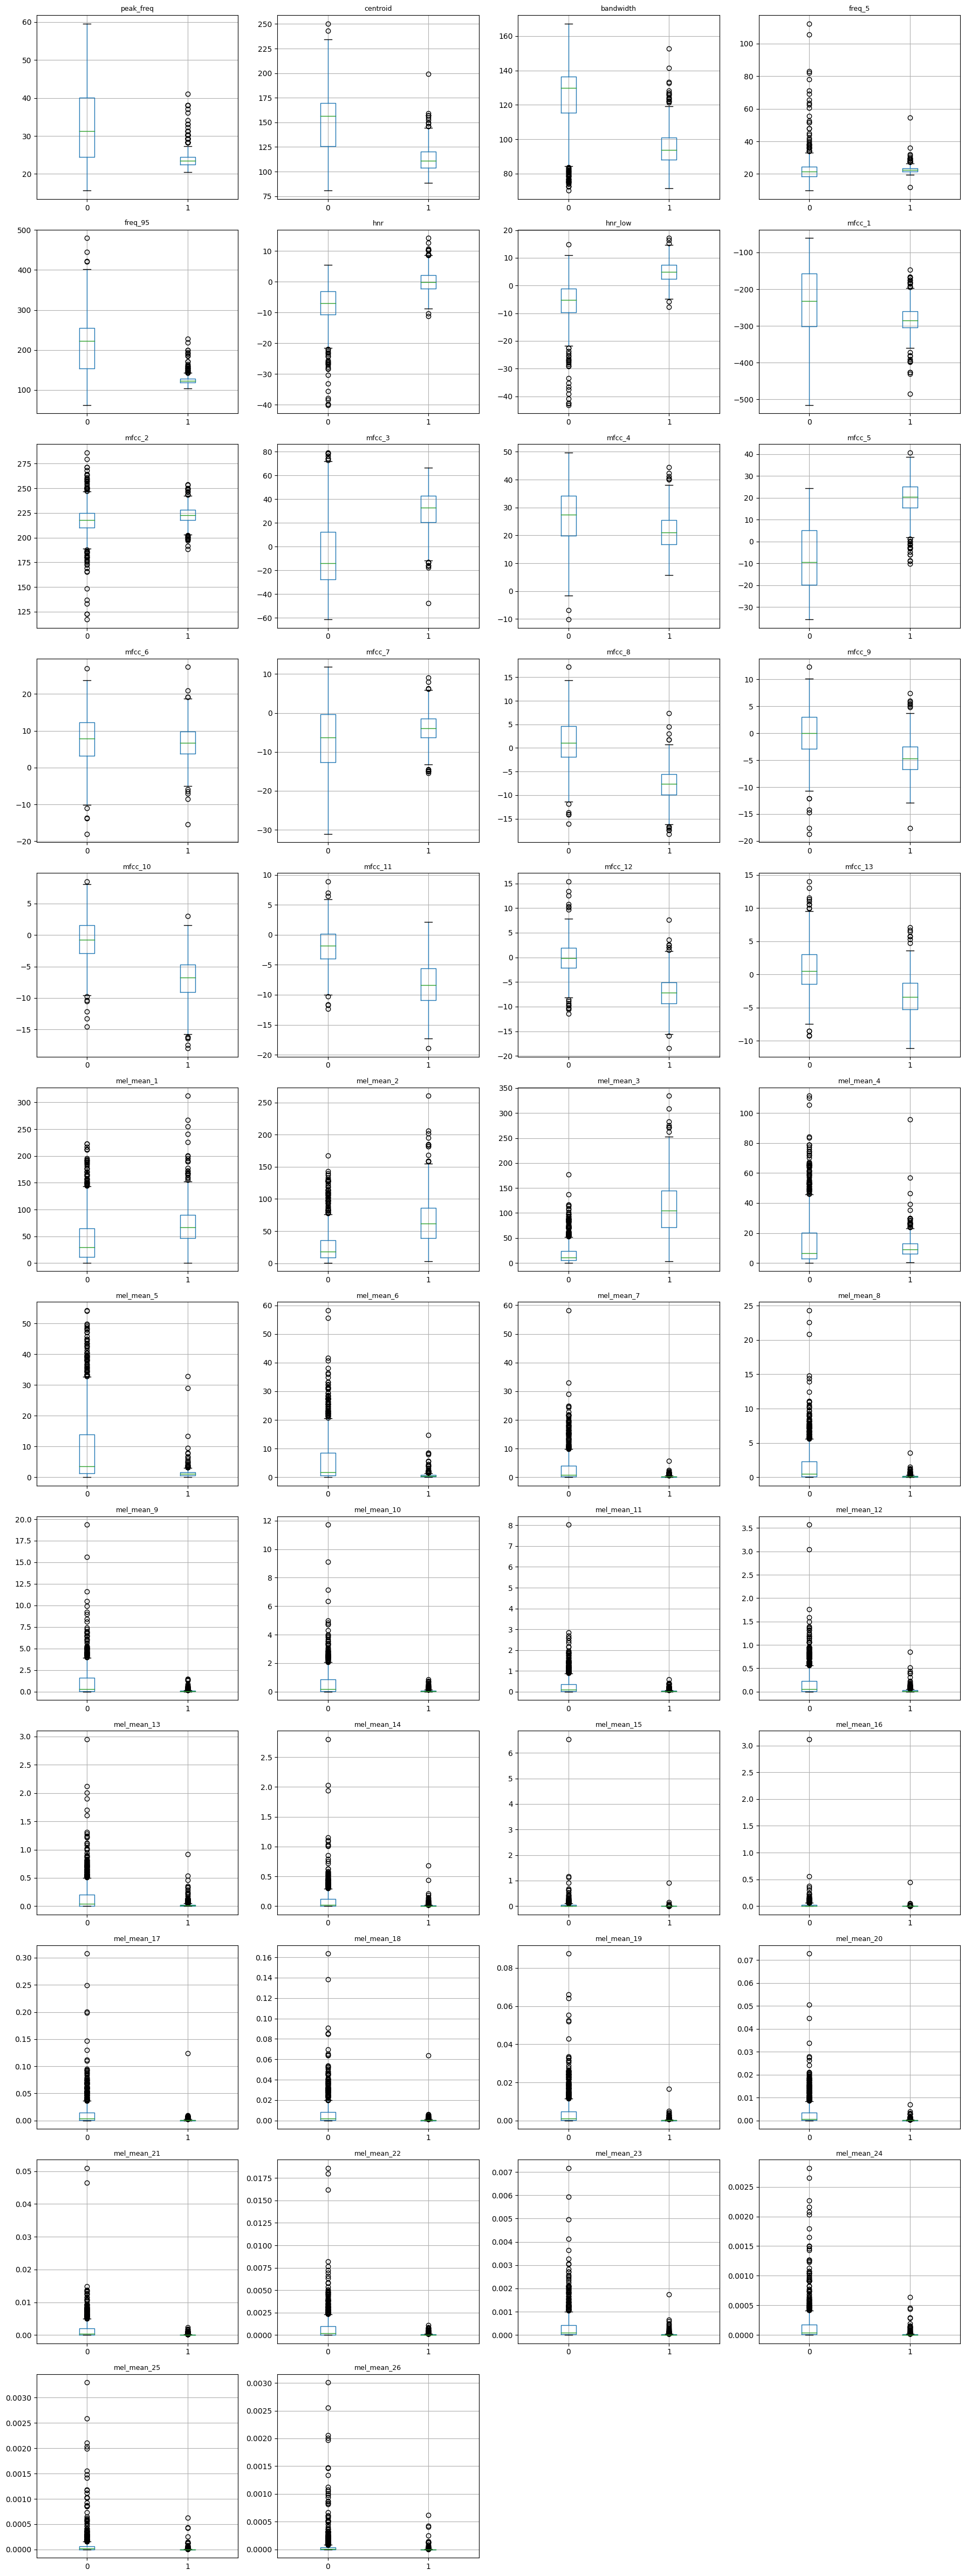

In [13]:
import matplotlib.pyplot as plt

# List of feature columns (everything except the label)
feature_cols = df.columns.drop("label")

# Determine the layout of the figure
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(feature_cols):

    df.boxplot(
        column=feature,
        by="label",
        ax=axes[i]
    )

    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("")
plt.tight_layout()

plt.show()

### Statistical Testing
Because our data does not follow a uniform distribution, we will use a **Mann-Whitney U test**

In [14]:
from scipy.stats import mannwhitneyu

In [15]:
# run the test on every feature
results = []

feature_cols = df.columns.drop("label")

for feature in feature_cols:

    background = df[df["label"] == 0][feature]
    rumble = df[df["label"] == 1][feature]

    stat, p = mannwhitneyu(
        background,
        rumble,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "U Statistic": stat,
        "P Value": p
    })

results = pd.DataFrame(results)

In [16]:
# rank the features
results = results.sort_values("P Value")

results.head(20)

,Feature,U Statistic,P Value
22,mel_mean_3,24267.0,2.163448e-177
6,hnr_low,24462.0,4.522191e-177
11,mfcc_5,26239.0,3.629485e-174
14,mfcc_8,447845.0,5.668158e-172
18,mfcc_12,439749.0,3.939618e-159
16,mfcc_10,436155.0,1.364763e-153
17,mfcc_11,435952.0,2.786072e-153
4,freq_95,425660.5,5.147505e-138
2,bandwidth,416770.0,2.016440e-125
5,hnr,58829.0,3.382393e-125


In [17]:
results["Significant"] = results["P Value"] < 0.05

results.head(20)

,Feature,U Statistic,P Value,Significant
22,mel_mean_3,24267.0,2.163448e-177,True
6,hnr_low,24462.0,4.522191e-177,True
11,mfcc_5,26239.0,3.629485e-174,True
14,mfcc_8,447845.0,5.668158e-172,True
18,mfcc_12,439749.0,3.939618e-159,True
16,mfcc_10,436155.0,1.364763e-153,True
17,mfcc_11,435952.0,2.786072e-153,True
4,freq_95,425660.5,5.147505e-138,True
2,bandwidth,416770.0,2.016440e-125,True
5,hnr,58829.0,3.382393e-125,True


In [18]:
results["Significant"].value_counts()

Significant
True    46
Name: count, dtype: int64

In [19]:
results[results["Significant"] == False]

,Feature,U Statistic,P Value,Significant


To reduce the chance of luck in our analysis, we will use a **Benjamini–Hochberg false discovery rate (FDR)** to adjust the p-va;ues

In [20]:
from statsmodels.stats.multitest import multipletests

results["Adjusted P"] = multipletests(
    results["P Value"],
    method="fdr_bh"
)[1]

results["Significant (FDR)"] = results["Adjusted P"] < 0.05

### Logistic Regression

In [21]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(1425, 46)
(476, 46)
label
0    892
1    533
Name: count, dtype: int64
label
0    303
1    173
Name: count, dtype: int64


In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [24]:
y_pred = model.predict(X_test_scaled)

### Classifier Evaluation

In [25]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[298   5]
 [  1 172]]


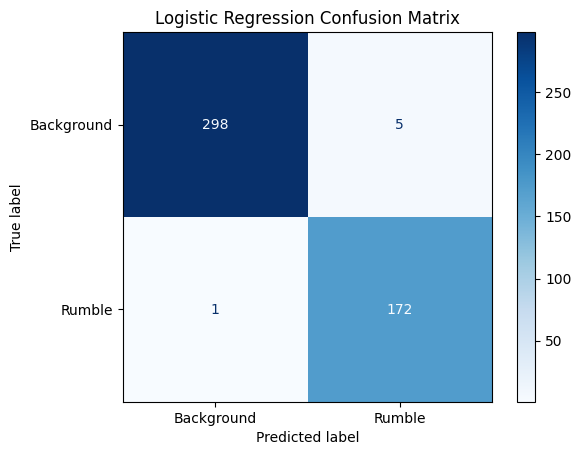

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Background", "Rumble"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       303
           1       0.97      0.99      0.98       173

    accuracy                           0.99       476
   macro avg       0.98      0.99      0.99       476
weighted avg       0.99      0.99      0.99       476



In [28]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.998


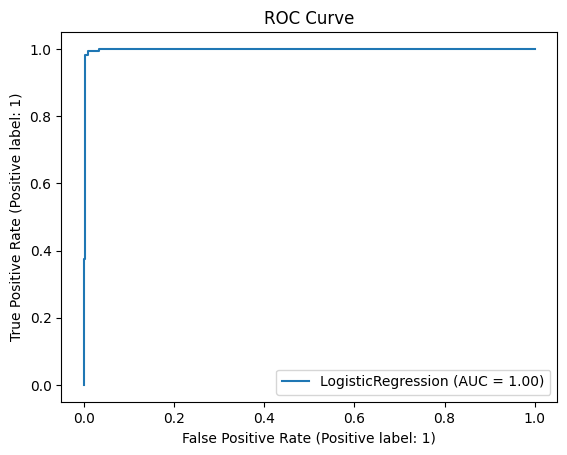

In [29]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve")
plt.show()

### Feature Importance from Logistic Regression

In [30]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute Coefficient
6,hnr_low,2.492970,2.492970
22,mel_mean_3,2.006414,2.006414
11,mfcc_5,1.128734,1.128734
37,mel_mean_18,-0.981021,0.981021
4,freq_95,-0.966268,0.966268
14,mfcc_8,-0.895644,0.895644
7,mfcc_1,-0.867886,0.867886
17,mfcc_11,-0.817903,0.817903
8,mfcc_2,-0.808459,0.808459
0,peak_freq,-0.756843,0.756843


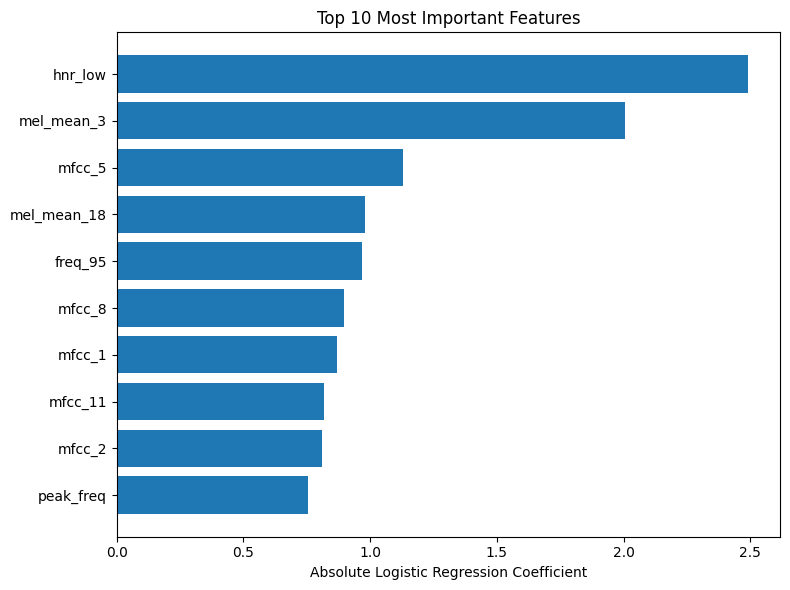

In [31]:
import matplotlib.pyplot as plt

top10 = coefficients.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Absolute Coefficient"]
)

plt.xlabel("Absolute Logistic Regression Coefficient")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [32]:
feature_summary = coefficients.merge(
    results,
    on="Feature"
)

feature_summary = feature_summary.sort_values(
    "Absolute Coefficient",
    ascending=False
)

feature_summary.head(10)

,Feature,Coefficient,Absolute Coefficient,U Statistic,P Value,Significant,Adjusted P,Significant (FDR)
0,hnr_low,2.492970,2.492970,24462.0,4.522191e-177,True,1.040104e-175,True
1,mel_mean_3,2.006414,2.006414,24267.0,2.163448e-177,True,9.951860e-176,True
2,mfcc_5,1.128734,1.128734,26239.0,3.629485e-174,True,5.565210e-173,True
3,mel_mean_18,-0.981021,0.981021,362581.0,5.724340e-62,True,9.079988e-62,True
4,freq_95,-0.966268,0.966268,425660.5,5.147505e-138,True,2.959815e-137,True
5,mfcc_8,-0.895644,0.895644,447845.0,5.668158e-172,True,6.518381e-171,True
6,mfcc_1,-0.867886,0.867886,320005.0,6.833606e-28,True,7.858646e-28,True
7,mfcc_11,-0.817903,0.817903,435952.0,2.786072e-153,True,1.830847e-152,True
8,mfcc_2,-0.808459,0.808459,164314.0,1.580794e-22,True,1.731346e-22,True
9,peak_freq,-0.756843,0.756843,379414.5,9.050076e-80,True,2.448844e-79,True


### Cross Validation with Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [35]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [36]:
rf_pred = rf_model.predict(X_test)

In [37]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       303
           1       0.96      0.99      0.97       173

    accuracy                           0.98       476
   macro avg       0.98      0.98      0.98       476
weighted avg       0.98      0.98      0.98       476



### RandomForest Feature Importance

In [38]:
import pandas as pd

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
6,hnr_low,0.144259
22,mel_mean_3,0.119525
14,mfcc_8,0.097640
4,freq_95,0.075044
11,mfcc_5,0.073913
18,mfcc_12,0.065955
2,bandwidth,0.049710
17,mfcc_11,0.048005
16,mfcc_10,0.044852
5,hnr,0.037845


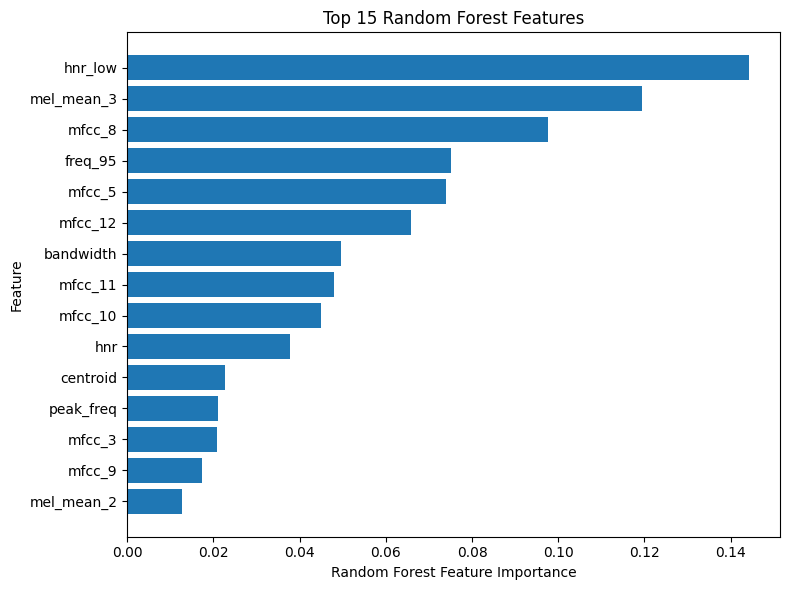

In [39]:
import matplotlib.pyplot as plt

top15 = rf_importance.head(15)

plt.figure(figsize=(8,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [40]:
# Mann-Whitney U ranking
mw_rank = results.copy()

mw_rank = mw_rank.sort_values("P Value")

mw_rank["MW Rank"] = range(1, len(mw_rank)+1)

mw_rank = mw_rank[[
    "Feature",
    "MW Rank",
    "P Value"
]]

# Logistic Regression ranking
lr_rank = coefficients.copy()

lr_rank = lr_rank.sort_values(
    "Absolute Coefficient",
    ascending=False
)

lr_rank["LR Rank"] = range(1, len(lr_rank)+1)

lr_rank = lr_rank[[
    "Feature",
    "Coefficient",
    "Absolute Coefficient",
    "LR Rank"
]]

# Random Forest ranking
rf_rank = rf_importance.copy()

rf_rank = rf_rank.sort_values(
    "Importance",
    ascending=False
)

rf_rank["RF Rank"] = range(1, len(rf_rank)+1)

rf_rank = rf_rank[[
    "Feature",
    "Importance",
    "RF Rank"
]]

# merge
comparison = (
    mw_rank
    .merge(lr_rank, on="Feature")
    .merge(rf_rank, on="Feature")
)

# add overall ranking
comparison["Average Rank"] = (
    comparison["MW Rank"] +
    comparison["LR Rank"] +
    comparison["RF Rank"]
) / 3
comparison = comparison.sort_values("Average Rank")
comparison = comparison[[
    "Feature",
    "P Value",
    "Coefficient",
    "Importance",
    "MW Rank",
    "LR Rank",
    "RF Rank",
    "Average Rank"
]]

comparison.head(20)

,Feature,P Value,Coefficient,Importance,MW Rank,LR Rank,RF Rank,Average Rank
1,hnr_low,4.522191e-177,2.492970,0.144259,2,1,1,1.333333
0,mel_mean_3,2.163448e-177,2.006414,0.119525,1,2,2,1.666667
2,mfcc_5,3.629485e-174,1.128734,0.073913,3,3,5,3.666667
3,mfcc_8,5.668158e-172,-0.895644,0.097640,4,6,3,4.333333
7,freq_95,5.147505e-138,-0.966268,0.075044,8,5,4,5.666667
6,mfcc_11,2.786072e-153,-0.817903,0.048005,7,8,8,7.666667
9,hnr,3.382393e-125,0.594300,0.037845,10,14,10,11.333333
5,mfcc_10,1.364763e-153,-0.474721,0.044852,6,20,9,11.666667
16,peak_freq,9.050076e-80,-0.756843,0.021010,17,10,12,13.000000
11,mel_mean_2,5.810203e-102,-0.521844,0.012689,12,16,15,14.333333
